In [1]:
import os
from pathlib import Path
import zarr
import numpy as np
import pandas as pd
from geff import read
import matplotlib.pyplot as plt
import napari
from napari.utils import nbscreenshot

In [4]:
# DATA LOCATION
INPUT_ROOT= Path('data/biohub-cell-tracking-during-development/')

# DISPLAY FOLDERS AND FILES INSIDE THE INPUT ROOT
if INPUT_ROOT.exists():
    for path in sorted(INPUT_ROOT.iterdir()):
        print(path.name)
else:
    print(f"Folder {INPUT_ROOT.name} not found!")
    # check parent folder
    parent_folder = INPUT_ROOT.parent
    if parent_folder.exists():
        print(f"\nAvailable folder {parent_folder}:")
        for path in sorted(parent_folder.iterdir()):
            print(path.name)
    else:
        print(f"Parent folder {parent_folder} found!")

sample_submission.csv
test
train


In [5]:
train_root = INPUT_ROOT/"train"
test_root = INPUT_ROOT/"test"

train_entries = sorted(train_root.iterdir())
test_entries = sorted(test_root.iterdir())

print(F"Number of train entries: {len(train_entries)}")
print(F"Number of test entries: {len(test_entries)}")

print("\nFirst five train entries:")
for path in train_entries[:5]:
    print(path.name)

print("\nFirst five test entries:")
for path in test_entries[:5]:
    print(path.name)

Number of train entries: 8
Number of test entries: 4

First five train entries:
6bba_0c7fa718.geff
6bba_0c7fa718.zarr
6bba_0e7c0d07.geff
6bba_0e7c0d07.zarr
6bba_1d0d8384.geff

First five test entries:
44b6_0113de3b.zarr
44b6_0b24845f.zarr
6bba_05b6850b.zarr
6bba_05db0fb1.zarr


## File Inspection
### Inspect .zarr file

In [6]:
zarr_paths = sorted(list(train_root.glob("*.zarr")))
geff_paths = sorted(list(train_root.glob("*.geff")))

In [7]:
# zarr sample
zarr_file_path = train_root/"6bba_0c7fa718.zarr"

# open zarr hierarchy
z_root = zarr.open(zarr_file_path, mode='r')
# inspect root hierarchy structure
zarr_root_keys = list(z_root.keys())

# main image array
main_array = z_root['0']
print(f"Shape: {main_array.shape}")
print(f"Data Type: {main_array.dtype}")


Shape: (100, 64, 256, 256)
Data Type: uint16


**Notes**: Shape represents (Time, Depth, Height, width)
- T = 100, means that there are 100 time points each zarr file. Furthermore, there are 100 moments of image captured. For example, if the microscope is set to record every one minute, means that this data records cell movement for 100 minutes.
- Z = 64, means each 3D frame has 64 slices (optical depth). Unlike flat 2D image captured by regular camera or phone, this specialized microscope captured the object (cell) optically from bottom to topmost part. So every time, there are 64 stack of images. This make it possible for us to observe whether the cells move up, down, or overlap to each other.
- Y & X = 256, means the size is 256 x 256 voxels. The height and the weight of each slices in pixels. 
- Unsigned integer 16-bit (Uint16). Standard images, usually use uint8, which ranges from 0 to 255. `uint16` ranges from 0 to 65.535, meaning that the light intensity is wider. This is super important to capture the fluorence signal from the cells so that it can capture all cells, brightest and very faint light intensity.



### Inspect .geff file (Ground-Truth Targets)

In [11]:
geff_file_path = train_root/"6bba_0c7fa718.geff"

graph, _ = read(geff_file_path, backend='networkx')

node_data = list(graph.nodes(data=True))

print(f"Total nodes detected: {graph.number_of_nodes()}")
print(f"Temporal links (number of edges): {graph.number_of_edges()}")

# first 10 nodes and attributes
print("\nFirst 10 nodes:")
for node in node_data:
    print(node)

Total nodes detected: 704
Temporal links (number of edges): 659

First 10 nodes:
(1000002, {'z': 44, 't': 0, 'x': 158, 'y': 152})
(1000004, {'z': 35, 't': 0, 'x': 175, 'y': 252})
(1000007, {'z': 39, 't': 0, 'x': 238, 'y': 174})
(1000011, {'z': 43, 't': 0, 'x': 199, 'y': 146})
(1000012, {'z': 44, 't': 0, 'x': 217, 'y': 240})
(1000017, {'z': 49, 't': 0, 'x': 115, 'y': 117})
(1000019, {'z': 52, 't': 0, 'x': 132, 'y': 240})
(1000020, {'z': 55, 't': 0, 'x': 251, 'y': 148})
(1000021, {'z': 55, 't': 0, 'x': 126, 'y': 194})
(2000035, {'z': 36, 't': 1, 'x': 170, 'y': 250})
(2000038, {'z': 39, 't': 1, 'x': 231, 'y': 172})
(2000039, {'z': 43, 't': 1, 'x': 192, 'y': 144})
(2000043, {'z': 44, 't': 1, 'x': 209, 'y': 239})
(2000044, {'z': 44, 't': 1, 'x': 150, 'y': 152})
(2000050, {'z': 50, 't': 1, 'x': 109, 'y': 114})
(2000052, {'z': 53, 't': 1, 'x': 123, 'y': 234})
(2000054, {'z': 53, 't': 1, 'x': 248, 'y': 145})
(2000058, {'z': 55, 't': 1, 'x': 120, 'y': 190})
(3000065, {'z': 36, 't': 2, 'x': 165,

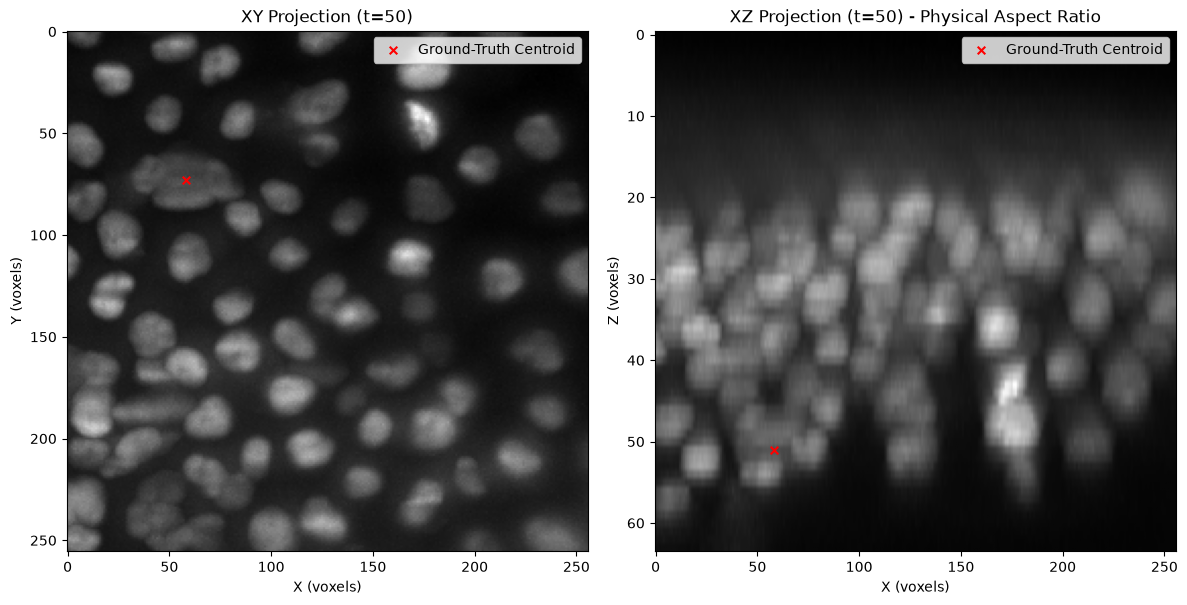

In [32]:
def visualize_frame_with_nodes(zarr_array, graph, t_frame=50):
    # Extract 3D raw volume for timepoint t_frame
    # shape: (Z, Y, X)
    volume_3d = zarr_array[t_frame]
    
    # Extract ground-truth nodes for this exact timepoint
    nodes_at_t = [
        data for node_id, data in graph.nodes(data=True) 
        if data.get('t') == t_frame
    ]
    
    # Separate centroid coordinates
    z_coords = [n['z'] for n in nodes_at_t]
    y_coords = [n['y'] for n in nodes_at_t]
    x_coords = [n['x'] for n in nodes_at_t]
    
    # Compute 2D Maximum Intensity Projections (MIP)
    mip_xy = np.max(volume_3d, axis=0) # Compress Z-axis
    mip_xz = np.max(volume_3d, axis=1) # Compress Y-axis
    
    # Plot projections with centroid overlays
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Plot XY projection (Y vs X)
    axes[0].imshow(mip_xy, cmap='gray')
    axes[0].scatter(x_coords, y_coords, color='red', s=30, marker='x', label='Ground-Truth Centroid')
    axes[0].set_title(f"XY Projection (t={t_frame})")
    axes[0].set_xlabel("X (voxels)")
    axes[0].set_ylabel("Y (voxels)")
    axes[0].legend()
    
    # Plot XZ projection (Z vs X)
    axes[1].imshow(mip_xz, cmap='gray', aspect=1.625/0.40625) # Apply physical aspect ratio
    axes[1].scatter(x_coords, z_coords, color='red', s=30, marker='x', label='Ground-Truth Centroid')
    axes[1].set_title(f"XZ Projection (t={t_frame}) - Physical Aspect Ratio")
    axes[1].set_xlabel("X (voxels)")
    axes[1].set_ylabel("Z (voxels)")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# Run visualization on frame 0
visualize_frame_with_nodes(main_array, graph, t_frame=50)

In [ ]:
volume_3d

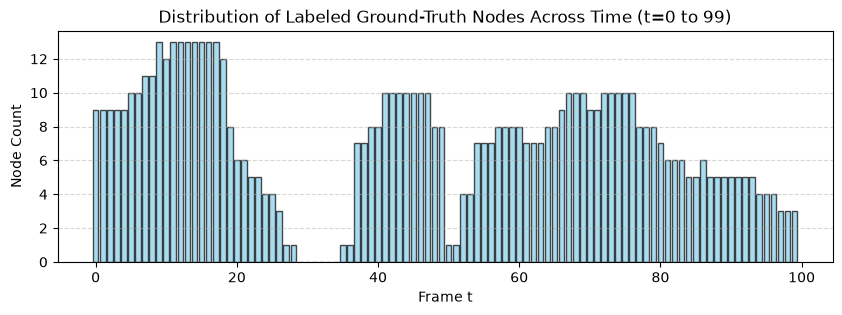

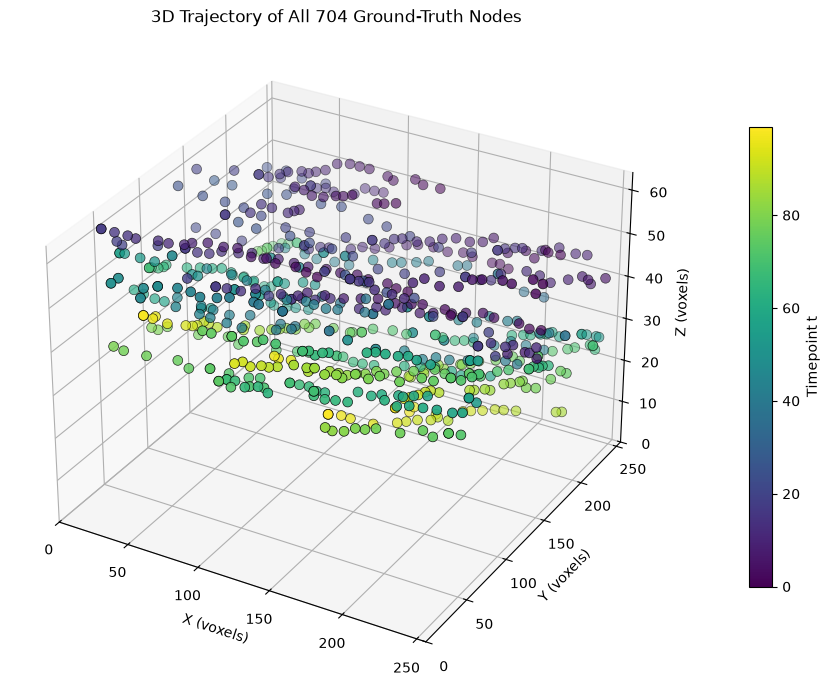

In [13]:
import matplotlib.pyplot as plt
from collections import Counter

# Extract node coordinate attributes
node_data = [data for _, data in graph.nodes(data=True)]

t_coords = [n['t'] for n in node_data]
z_coords = [n['z'] for n in node_data]
y_coords = [n['y'] for n in node_data]
x_coords = [n['x'] for n in node_data]

# PLOT 1: Labeled Node Count per Time Frame
frame_counts = Counter(t_coords)
frames = list(range(100))
counts = [frame_counts.get(t, 0) for t in frames]

plt.figure(figsize=(10, 3))
plt.bar(frames, counts, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Frame t')
plt.ylabel('Node Count')
plt.title('Distribution of Labeled Ground-Truth Nodes Across Time (t=0 to 99)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# PLOT 2: 3D Spatial Trajectory of All 52 Nodes
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Draw the scatter points colored by time frame
scatter = ax.scatter(
    x_coords, y_coords, z_coords, 
    c=t_coords, cmap='viridis', 
    s=50, edgecolors='k', linewidth=0.5
)

# Constrain axes to raw image spatial shape (256, 256, 64)
ax.set_xlim(0, 256)
ax.set_ylim(0, 256)
ax.set_zlim(0, 64)

ax.set_xlabel('X (voxels)')
ax.set_ylabel('Y (voxels)')
ax.set_zlabel('Z (voxels)')
ax.set_title(f"3D Trajectory of All {len(node_data)} Ground-Truth Nodes")

# Add time colorbar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Timepoint t')

plt.tight_layout()
plt.show()

## Summary

In [14]:
def summarize_trainng_data(train_dir):
    summary_records = []

    # Sorted list of zarr paths
    zarr_paths = sorted(train_root.glob("*.zarr"))

    for zarr_path in zarr_paths:
        geff_path = zarr_path.with_suffix(".geff")
        dataset_name = zarr_path.stem

        # Read zarr dimension
        z_root = zarr.open(zarr_path, mode='r')
        main_array = z_root['0']
        t_dim, z_dim, y_dim, x_dim = main_array.shape

        # Read GEFF Graph stats
        if geff_path.exists:
            graph, _ = read(geff_path, backend='networkx')
            num_nodes = graph.number_of_nodes()
            num_edges = graph.number_of_edges()

            # count division event (od == 2)
            divisions = sum(1 for n in graph.nodes() if graph.out_degree(n) == 2)
        else:
            num_nodes, num_edges, divisions = 0, 0, 0

        summary_records.append({
            'dataset_name': dataset_name,
            'T': t_dim, 'Z': z_dim, 'Y': y_dim, 'X': x_dim,
            'total_nodes': num_nodes,
            'total_edges': num_edges,
            'total_divisions': divisions,
            'nodes_per_frame': num_nodes / t_dim if t_dim > 0 else 0
        })

    return  pd.DataFrame(summary_records)

In [10]:
summary_data = summarize_trainng_data(train_root)
summary_data.describe()

,T,Z,Y,X,total_nodes,total_edges,total_divisions,nodes_per_frame
count,199.0,199.0,199.0,199.0,199.000000,199.000000,199.000000,199.000000
mean,100.0,64.0,256.0,256.0,669.939698,647.653266,0.758794,6.699397
std,0.0,0.0,0.0,0.0,421.410482,406.297691,1.069367,4.214105
min,100.0,64.0,256.0,256.0,50.000000,49.000000,0.000000,0.500000
25%,100.0,64.0,256.0,256.0,294.000000,286.000000,0.000000,2.940000
50%,100.0,64.0,256.0,256.0,659.000000,639.000000,0.000000,6.590000
75%,100.0,64.0,256.0,256.0,939.500000,918.500000,1.000000,9.395000
max,100.0,64.0,256.0,256.0,1950.000000,1879.000000,5.000000,19.500000


### NOTES
We use `std` and `percentiles` to understand how the data is distributed through space.
1) **Invariants (The Constants)**: If we look at the `std` row for `T, Z, Y, X`. It is exactly 0.0. This means that every rows in those columns are exactly the same. All 199 dataset has the same T, Z, Y, and X.
2) **Center of Mass (Mean vs Median)**: When we look at the `total_nodes`, the `mean` is 669.9 and the `50%` (median) is 659.0. Because the mean and median are almost identical, the total number of cells is symmetrically distributed. No extreme skewness (like one dataset having 100,000 nodes while others have 10). This means that we don't have to write complex sampling stratifications to balance dense vs. sparse dataset during training batch generation.
3) **Extreme Rarity (50% vs 75% Marks)**: In the column of `total_divisions`, the `50%` mark is 0.0 and the `75%` mark is 1.0. The `mean` is < 1.0. This means that in this dataset, mitosis rarely happen. This is crucial since our model need to be able to detect cells, the movement, and the division accurately. Furthermore, any model can guess no division for every frame and still got high accuracy. For that, we need to implement heavy class weighting to penalize missed divisions.
4) **Density Variance (Standard Deviation)**: when we look at the `nodes_per_frame`, the `mean` is 6.69 but the `std` is 4.21 which is very large relative to mean. Data density fluctuates wildly. The 25% quartile has $< 3$ nodes per frame, while the maximum has roughly $20$. This answers the previous logic challenge. A single, rigid global probability threshold for cell detection will fail. A threshold tuned for a dense environment (19.5 nodes) will suppress true positives in a sparse environment (0.5 nodes). We will likely need adaptive thresholding or Local Maxima extraction rather than a flat global cutoff.

In [11]:
summary_data.tail()

,dataset_name,T,Z,Y,X,total_nodes,total_edges,total_divisions,nodes_per_frame
194,6bba_fbc898dc,100,64,256,256,655,639,0,6.55
195,6bba_fc516dc6,100,64,256,256,788,762,0,7.88
196,6bba_fc5f39dc,100,64,256,256,471,458,2,4.71
197,6bba_fc83837d,100,64,256,256,957,923,0,9.57
198,6bba_fe670320,100,64,256,256,716,680,2,7.16


## Custom Dataset

In [15]:
zarr_paths = sorted(list(train_root.glob("*.zarr")))
geff_paths = sorted(list(train_root.glob("*.geff")))

In [16]:
import numpy as np
import torch
import zarr
from geff import read 
from torch.utils.data import Dataset


def get_start_coords(size, p_size):
    coords = list(range(0, size, p_size))

    # If the last coordinate plus patch size exceeds the boundary,
    # adjust it backwards to exactly fit the edge.
    if coords[-1] + p_size > size:
        coords[-1] = size - p_size

    # no duplicates if the volume size is perfectly divisible
    return sorted(list(set(coords)))

def get_first_array(zarr_node):
    """Mencari array gambar 4D secara otomatis di dalam Zarr Group/Sub-group."""
    if hasattr(zarr_node, "shape"):
        return zarr_node
    if hasattr(zarr_node, "keys"):
        for key in zarr_node.keys():
            item = zarr_node[key]
            array = get_first_array(item)
            if array is not None:
                return array
    return None


class CellPatchDataset(Dataset):

    def __init__(
        self, zarr_paths, geff_paths, patch_size=(32, 128, 128), sigma=2.0
    ):
        self.zarr_paths = zarr_paths
        self.geff_paths = geff_paths
        self.patch_size = patch_size
        self.sigma = sigma
        self.patch_mapping = []

        # 1. OPTIMASI CACHING (Primitive Struct):
        # Menyimpan koordinat sel sebagai dict of numpy array agar DataLoader Multiprocessing
        # tidak memicu kebocoran RAM CPU (OOM) di Kaggle.
        self.node_cache = {}
        for g_path in self.geff_paths:
            graph, _ = read(str(g_path), backend="networkx")
            for node_id, attrs in graph.nodes(data=True):
                key = (str(g_path), attrs["t"])
                if key not in self.node_cache:
                    self.node_cache[key] = []
                self.node_cache[key].append((attrs["z"], attrs["y"], attrs["x"]))

        # Konversi list koordinat menjadi NumPy Array (int32)
        for key in self.node_cache:
            self.node_cache[key] = np.array(
                self.node_cache[key], dtype=np.int32
            )

        pz, py, px = self.patch_size

        for z_path, g_path in zip(self.zarr_paths, self.geff_paths):
            zarr_root = zarr.open(str(z_path), mode="r")
            zarr_array = get_first_array(zarr_root)

            if zarr_array is None:
                raise ValueError(
                    f"Tidak ditemukan array gambar di dalam {z_path}"
                )

            num_t, size_z, size_y, size_x = zarr_array.shape

            z_starts = get_start_coords(size_z, pz)
            y_starts = get_start_coords(size_y, py)
            x_starts = get_start_coords(size_x, px)

            for t in range(num_t):
                for z in z_starts:
                    for y in y_starts:
                        for x in x_starts:
                            self.patch_mapping.append({
                                 "zarr_path": str(z_path),
                                "geff_path": str(g_path),
                                "t": t,
                                "z_start": z,
                                "y_start": y,
                                "x_start": x,
                            })

    def __len__(self):
        return len(self.patch_mapping)

    def _draw_3d_gaussian(self, heatmap, center):
        cz, cy, cx = center
        pz, py, px = heatmap.shape

        sigma_xy = self.sigma # base sigma for x and y

        # Scale down Z sigma based on physical resolution ratio
        sigma_z = self.sigma * (0.40625/1.625) 

        # Calculate bounding box using the maximum sigma
        radius = int(3 * max(sigma_xy, sigma_z)) 

        z_min, z_max = max(0, int(cz - radius)), min(pz, int(cz + radius + 1))
        y_min, y_max = max(0, int(cy - radius)), min(py, int(cy + radius + 1))
        x_min, x_max = max(0, int(cx - radius)), min(px, int(cx + radius + 1))

        zz, yy, xx = np.ogrid[z_min:z_max, y_min:y_max, x_min:x_max]


        # Apply axis-specific variance to the Gaussian distance formula
        dist_sq = ((zz - cz) ** 2) / (sigma_z ** 2) + ((yy - cy) ** 2) / (sigma_xy ** 2) + ((xx - cx) ** 2) / (sigma_xy ** 2)

        gaussian = np.exp(-dist_sq / 2.0)

        heatmap[z_min:z_max, y_min:y_max, x_min:x_max] = np.maximum(
            heatmap[z_min:z_max, y_min:y_max, x_min:x_max], gaussian
        )

    def __getitem__(self, idx):
        info = self.patch_mapping[idx]
        zarr_path = info["zarr_path"]
        geff_path = info["geff_path"]
        t = info["t"]
        z_s, y_s, x_s = info["z_start"], info["y_start"], info["x_start"]
        pz, py, px = self.patch_size

        zarr_root = zarr.open(zarr_path, mode="r")
        zarr_array = get_first_array(zarr_root)

        input_patch = zarr_array[
            t, z_s : z_s + pz, y_s : y_s + py, x_s : x_s + px
        ].astype(np.float32)

        # 2. OPTIMASI NORMALISASI (Percentile Clipping Standar nnU-Net):
        # Memotong outlier 0.5% & 99.5% agar kontras sel konsisten tanpa memperbesar noise background.
        p_low, p_high = np.percentile(input_patch, (0.5, 99.5))
        if p_high > p_low:
            input_patch = np.clip(input_patch, p_low, p_high)
            input_patch = (input_patch - p_low) / (p_high - p_low)
        else:
            input_patch = np.zeros_like(input_patch)

        target_heatmap = np.zeros(self.patch_size, dtype=np.float32)

        # Ambil koordinat sel dari Primitive Cache
        nodes_at_t = self.node_cache.get((geff_path, t), np.array([]))

        for nz, ny, nx in nodes_at_t:
            if (
                (z_s <= nz < z_s + pz)
                and (y_s <= ny < y_s + py)
                and (x_s <= nx < x_s + px)
            ):
                rel_z = nz - z_s
                rel_y = ny - y_s
                rel_x = nx - x_s
                self._draw_3d_gaussian(target_heatmap, (rel_z, rel_y, rel_x))

        # 3. OPTIMASI MEMORY LAYOUT (Contiguous Memory):
        # Menyusun ulang memori array agar transfer CPU-ke-GPU di PyTorch berjalan maksimal.
        input_patch = np.ascontiguousarray(input_patch)
        target_heatmap = np.ascontiguousarray(target_heatmap)

        input_tensor = torch.from_numpy(input_patch).unsqueeze(0).float()
        target_tensor = torch.from_numpy(target_heatmap).unsqueeze(0).float()

        return input_tensor, target_tensor

Explanation can be found [here](notes/data_preprocessing.md)

## Test

Total patches successfully mapped: 159200

--- New Single-Item Test Results ---
Input Shape          : torch.Size([1, 32, 128, 128])
Target Shape         : torch.Size([1, 32, 128, 128])
Input Range (Min-Max): 0.00 s/d 1.00
Target Max (Gaussian): 1.00
Is Contiguous Memory : True


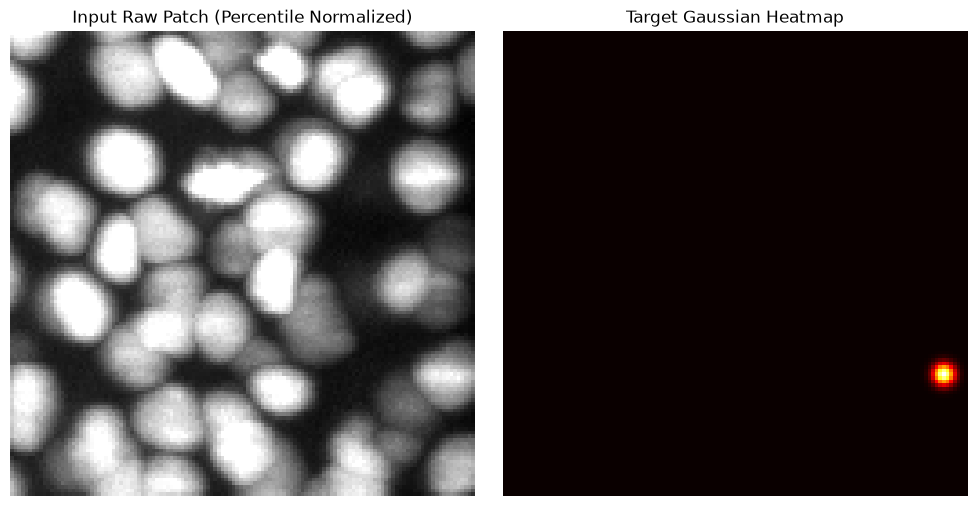

In [22]:
# 1. Inisialisasi ulang dataset dengan kelas yang baru
dataset = CellPatchDataset(zarr_paths, geff_paths)

print(f"Total patches successfully mapped: {len(dataset)}")

# 2. Ambil sampel patch ke-7 (yang ada selnya)
inp_tensor, tgt_tensor = dataset[7]

print("\n--- New Single-Item Test Results ---")
print(f"Input Shape          : {inp_tensor.shape}")
print(f"Target Shape         : {tgt_tensor.shape}")
print(
    f"Input Range (Min-Max): {inp_tensor.min():.2f} s/d {inp_tensor.max():.2f}"
)
print(f"Target Max (Gaussian): {tgt_tensor.max():.2f}")
print(f"Is Contiguous Memory : {inp_tensor.is_contiguous()}")

# 3. Visualisasi sederhana
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(inp_tensor.squeeze().numpy().max(axis=0), cmap="gray")
axes[0].set_title("Input Raw Patch (Percentile Normalized)")
axes[0].axis("off")

axes[1].imshow(tgt_tensor.squeeze().numpy().max(axis=0), cmap="hot")
axes[1].set_title("Target Gaussian Heatmap")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Cek edge cases kelas

In [ ]:
import random
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm


def run_dataset_health_check(dataset, sample_size=500, num_workers=2):
    print("=== STARTING DATASET HEALTH CHECK ===")

    # -------------------------------------------------------------
    # UJI 1 & 2: Integritas Data (NaN/Inf) & Rasio Patch Berisi Sel
    # -------------------------------------------------------------
    print(
        f"\n[1/2] Checking {sample_size} random patches for data integrity"
        " & ratio..."
    )
    sample_indices = random.sample(
        range(len(dataset)), min(sample_size, len(dataset))
    )

    non_empty_count = 0
    nan_inf_found = False

    for idx in tqdm(sample_indices, desc="Checking patches"):
        inp, tgt = dataset[idx]

        # Cek NaN atau Inf
        if (
            torch.isnan(inp).any()
            or torch.isinf(inp).any()
            or torch.isnan(tgt).any()
            or torch.isinf(tgt).any()
        ):
            print(f"Error: NaN/Inf found on patch index {idx}!")
            nan_inf_found = True
            break

        # Hitung patch yang mengandung sel (target max > 0)
        if tgt.max() > 0:
            non_empty_count += 1

    if not nan_inf_found:
        print("Free from  NaN and Inf!")

    ratio = (non_empty_count / len(sample_indices)) * 100
    print(
        f"Patch Rasio Contains cell: {ratio:.2f}% ({non_empty_count} from"
        f" {len(sample_indices)} patch)"
    )

    if ratio < 5.0:
        print(
            "  Catatan: Rasio sel cukup rendah (<5%). Disarankan"
            " menggunakan Positivity-based Sampling saat training."
        )

    # -------------------------------------------------------------
    # UJI 3: Multiprocessing DataLoader (Kaggle RAM & Process Check)
    # -------------------------------------------------------------
    print(
        f"\n[2/2] Testing DataLoader Multiprocessing (num_workers={num_workers})..."
    )
    try:
        test_loader = DataLoader(
            dataset, batch_size=4, shuffle=True, num_workers=num_workers
        )
        for batch_idx, (b_inp, b_tgt) in enumerate(test_loader):
            if batch_idx == 5:
                break
        print(
            f"Multiprocessing (num_workers={num_workers}) ran smoothly"
            " without memory lock!"
        )
    except Exception as e:
        print(f"Error Multiprocessing: {e}")
        print(
            "   Saran: Di Kaggle, atur num_workers=2 atau num_workers=0 jika"
            " ada isu serialisasi."
        )

    print("\n======================================")
    print("HEALTH CHECK DONE - DATASET READY!")
    print("======================================")

In [24]:
run_dataset_health_check(dataset, sample_size=500, num_workers=2)

=== STARTING DATASET HEALTH CHECK ===

[1/2] Checking 500 random patch for data integrity & ratio...


Checking patches:   0%|          | 0/500 [00:00<?, ?it/s]

Free from  NaN and Inf!
Patch Rasio Contains cell: 43.20% (216 from 500 patch)

[2/2] Testing DataLoader Multiprocessing (num_workers=2)...
Multiprocessing (num_workers=2) ran smoothly without memory lock!

HEALTH CHECK DONE - DATASET READY!


## 3D U-Net

In [8]:
import torch.nn as nn
import torch.nn.functional as F

In [9]:
class UNet3D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        # ENCODER 
        self.enc1 = self._double_conv(in_channels, 16)
        self.pool1 = nn.MaxPool3d(kernel_size=2, stride=2)

        self.enc2 = self._double_conv(16, 32)
        self.pool2 = nn.MaxPool3d(kernel_size=2, stride=2)

        # BOTTLENECK
        self.bottleneck = self._double_conv(32, 64)

        # DECODER 
        self.upconv2 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec2 = self._double_conv(64, 32)

        self.upconv1 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)
        self.dec1 = self._double_conv(32, 16)

        # FINAL OUTPUT
        self.final_conv = nn.Conv3d(16, out_channels, kernel_size=1)

    def _double_conv(self, in_c, out_c):
        # Return an nn.Sequential block
        return nn.Sequential(
            nn.Conv3d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Pass 'x' through enc1, then pool1
        x1 = self.enc1(x)
        p1 = self.pool1(x1)

        # Pass through enc2, then pool2
        x2 = self.enc2(p1)
        p2 = self.pool2(x2)

        # Pass through the bottleneck
        bn = self.bottleneck(p2)

        # Upsample using upconv2, concatenate with enc2 (skip connection), pass through dec2
        up2 = self.upconv2(bn)
        cat2 = torch.cat([up2, x2], dim=1)
        d2 = self.dec2(cat2)


        # Upsample using upconv1, concatenate with enc1, pass through dec1
        up1 = self.upconv1(d2)
        cat1 = torch.cat([up1, x1], dim=1)
        d1 = self.dec1(cat1)

        # Pass through final_conv and return
        out = self.final_conv(d1)

        return out

        

Explanation can be found [here](notes/model.md)

## Loss function and Training Loop

In [ ]:
import torch.optim as optim

# Initialize pipeline
# deteksi device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(F"Device used: {device}")


model = UNet3D(in_channels=1, out_channels=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

def jaccard_loss_per_sample(pred, target, smooth=1e-5):
    # Flatten starting from dimension 1 to keep batches isolated.
    # Flatten mulai dari dimensi 1 untuk menjaga isolasi antar batch
    # Bentuk berubah dari (B, C, Z, Y, X) menjadi (B, N)
    pred_flat = pred.flatten(start_dim=1)
    target_flat = target.flatten(start_dim=1)

    # Calculate intersection PER SAMPLE.
    # Hitung intersection PER SAMPEL (dimensi 1)
    intersection = (pred_flat * target_flat).sum(dim=1)

    # Calculate union PER SAMPLE using .sum(dim=1)
    # Hitung union PER SAMPEL (dimensi 1)
    union = pred_flat.sum(dim=1) + target_flat.sum(dim=1) - intersection

    # Calculate the dice array (shape B) and return its mean()
    # Hitung array dice score (ukuran B), ubah menjadi loss, lalu rata-ratakan
    jaccard_score = (intersection + smooth) / (union + smooth)
    
    return 1.0 - jaccard_score.mean()

# Training epoch
model.train()
for batch_idx, (inputs, targets) in enumerate(dataloader):
    inputs, targets = inputs.to(device), targets.to(device)

    optimizer.zero_grad()

    # forward pass
    raw_logits = model(inputs)

    # Activation
    # Apply the correct mathematical activation function to raw_logits
    # Karena model mengeluarkan raw_logits (angka dari minus tak terhingga s/d positif tak terhingga),
    # kita WAJIB menggunakan Sigmoid untuk memeras angkanya menjadi probabilitas 0.0 sampai 1.0.
    # Jika tidak, perhitungan Dice Loss akan kacau (bisa bernilai negatif).
    predictions = torch.sigmoid(raw_logits)

    # backward pass
    loss = jaccard_loss_per_sample(predictions, targets)

    loss.backward()
    optimizer.step()

    if batch_idx % 10 == 0:
        print(f"Batch {batch_idx} | Dice Loss: {loss.item():.4f}")

Device used: cpu
Batch 0 | Dice Loss: 0.9997
Batch 10 | Dice Loss: 0.9999
Batch 20 | Dice Loss: 0.9999
Batch 30 | Dice Loss: 0.9997


KeyboardInterrupt: 

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# 1. Inisialisasi Model & Trik Bias Layer Terakhir
model = UNet3D(in_channels=1, out_channels=1)
nn.init.constant_(model.final_conv.bias, -4.0) # Paksa tebakan awal mendekati 0.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 2. Loss Function Kombinasi (BCE + Dice)
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, raw_logits, targets):
        bce_loss = self.bce(raw_logits, targets)
        
        preds = torch.sigmoid(raw_logits)
        pred_f = preds.flatten()
        target_f = targets.flatten()
        
        intersection = (pred_f * target_f).sum()
        union = pred_f.sum() + target_f.sum()
        dice_loss = 1.0 - (2.0 * intersection + 1e-5) / (union + 1e-5)
        
        return bce_loss + dice_loss

criterion = BCEDiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 3. Ambil TEPAT 1 Batch untuk Di-overfit
local_dataset = CellPatchDataset(zarr_paths[:1], geff_paths[:1])
dataloader = DataLoader(local_dataset, batch_size=1, shuffle=False)

single_inputs, single_targets = next(iter(dataloader))
single_inputs = single_inputs.to(device, dtype=torch.float32)
single_targets = single_targets.to(device, dtype=torch.float32)

print(f"Device: {device} | Memulai Uji Overfit 1 Batch (15 Iterasi)...")

# 4. Melatih 1 Batch Berulang-ulang
model.train()
for step in range(1, 16):
    optimizer.zero_grad()
    
    raw_logits = model(single_inputs)
    loss = criterion(raw_logits, single_targets)
    
    loss.backward()
    optimizer.step()
    
    print(f"Step {step:02d}/15 | Combined Loss: {loss.item():.4f}")

Device: cpu | Memulai Uji Overfit 1 Batch (15 Iterasi)...
Step 01/15 | Combined Loss: 1.0187
Step 02/15 | Combined Loss: 1.0177
Step 03/15 | Combined Loss: 1.0166
Step 04/15 | Combined Loss: 1.0154
Step 05/15 | Combined Loss: 1.0142
Step 06/15 | Combined Loss: 1.0137
Step 07/15 | Combined Loss: 1.0133
Step 08/15 | Combined Loss: 1.0130
Step 09/15 | Combined Loss: 1.0127
Step 10/15 | Combined Loss: 1.0124
Step 11/15 | Combined Loss: 1.0122
Step 12/15 | Combined Loss: 1.0119
Step 13/15 | Combined Loss: 1.0117
Step 14/15 | Combined Loss: 1.0115
Step 15/15 | Combined Loss: 1.0114


## Extract Centroids

In [ ]:
from skimage.feature import peak_local_max
import numpy as np

def extract_centroids(probability_volume, threshold=0.5, min_dist=5):
    # Ensure the probability_volume is a 3D numpy array
    # Jika inputnya masih berupa tensor PyTorch (misal dari GPU Kaggle), kita turunkan ke CPU dan ubah ke NumPy
    if isinstance(probability_volume, torch.Tensor):
        probability_volume = probability_volume.detach().cpu().numpy()

    # Model U-Net kita mengeluarkan format (Batch, Channel, Z, Y, X) -> misal (1, 1, 32, 128, 128)
    # np.squeeze akan membuang dimensi yang bernilai 1, menyisakannya murni 3D: (32, 128, 128)
    probability_volume = np.squeeze(probability_volume)

    # Validasi untuk memastikan tensornya benar-benar sudah 3D
    assert probability_volume.ndim == 3, f"Volume harus 3D, tapi didapat {probability_volume.ndim}D"
    
    # 1. Extract peaks
    # min_distance: radius piksel minimal antar titik sel agar tidak ada sel ganda
    # threshold_abs: batas minimal probabilitas (misal 0.5) agar diakui sebagai sel
    coordinates = peak_local_max(
        probability_volume,
        min_distance=min_dist,
        threshold_abs=threshold
    )
    
    # 2. Return as a list of (z, y, x) tuples
    return [tuple(coord) for coord in coordinates]

# centroids = extract_centroids(predictions, threshold=0.5, min_dist=5)
# print(centroids) -> Output: [(12, 64, 50), (28, 100, 25), ...]

## membedakan sell
Membedakan apakah dua puncak merupakan dua cell sama atau berbeda

In [30]:
from skimage.draw import line_nd
import math

# Helper function, calculate real physical distance
def calculate_physical_distance(peak_a, peak_b):
    # peak a and b are tuples (z, y, x)

    # Physical scaling factors
    z_scale = 1.625
    xy_scale = 0.40625

    # multiply z coords of peak_a and peak_b by z_scale
    # multiply the Y and X coords by xy_scale
    scaled_a = (peak_a[0] * z_scale, peak_a[1] * xy_scale, peak_a[2] * xy_scale)
    scaled_b = (peak_b[0] * z_scale, peak_b[1] * xy_scale, peak_b[2] * xy_scale)

    # calculate true physical Euclidean distance
    return math.dist(scaled_a, scaled_b)

def filter_peak_by_topo(probability_volume, candidate_peaks, merge_threshold=0.6, distance_threshold=15):
    """ 
    candidate_peaks: List of (z, y, x) tuples from peak_local_max with a very low min_dist.
    merge_threshold: If the 'ditch' between two close peaks stays above this value, merge them.
    distance_treshold: Max distance (in voxels) to even consider checking the ditch.
    """
    if len(candidate_peaks) == 0:
        return []

    # Sort the peaks based on their probability values (highest to lowest)
    # Ensuring the highest peak is evaluated first and preserved.
    peaks_with_probs = [(p, probability_volume[tuple(p)]) for p in candidate_peaks]
    peaks_with_probs.sort(key=lambda x: x[1], reverse=True)
    
    final_peaks =[]

    # loops to compare pairs of candidate peaks
    # If Peak A and Peak B are within a certain spatial distance (e.g., < 15 voxels):
    for current_peak, _ in peaks_with_probs:
        keep_peak = True

        # Compare this with the peaks that have passed the selection process.
        for valid_peak in final_peaks:
            # calculate spatial Euclidean distance
            dist = calculate_physical_distance(current_peak, valid_peak)

            # if the dist is close enough, check if they are one cell
            if dist < distance_threshold:

                # Draw a straight 3D line between two peaks (vertices) using line_nd
                ray_coords = line_nd(current_peak, valid_peak)

                # Extract the probability values along the line
                line_probabilities = probability_volume[ray_coords]

                # look for lowest point (the ditch) between the two points
                ditch_depth = np.min(line_probabilities)

                # topological decision
                if ditch_depth >= merge_threshold:
                    # the gap is too shallow (strong probability bridge) -> current peak and valid peak are the same cell
                    # Since valid peak has a higher probability due to sorting in step 1, we merge or dicard current peak
                    keep_peak = False
                    break # stop checking, discard current_peak

        if keep_peak:
            final_peaks.append(tuple(current_peak))

    return final_peaks

### Stage 1: Fundamentals (Temporal Edges)
With the spatial pipeline complete, we have a list of valid `(z, y, x)` centroids for Frame `t` and Frame `t+1`. The Kaggle competition requires linking these nodes to form a lineage graph (the .geff structure). We must formulate this as a Bipartite Graph Matching problem.

### Stage 2: Intuition (The Assignment Problem)
If we simply link a cell in Frame 1 to its geometrically closest neighbor in Frame 2, high-density environments will cause catastrophic failures. Two cells in Frame 1 might both find the exact same cell in Frame 2 to be their closest neighbor, resulting in overlapping tracking lines and an orphaned cell elsewhere.

To globally minimize the movement distance for all cells simultaneously without allowing two cells to claim the same target, scientists use the Hungarian Algorithm (also known as the Kuhn-Munkres algorithm).

### Stage 3: Scaffolding (The Cost Matrix)
To use the Hungarian algorithm (available via scipy.optimize.linear_sum_assignment), we must first build a 2D grid called a "Cost Matrix." This matrix computes the physical movement cost (distance) between every possible pair of cells across the two frames.

In [23]:
from scipy.optimize import linear_sum_assignment

def build_tracking_edges(nodes_t0, nodes_t1, max_distance=15.0):
    """ 
    nodes_t0: list of valid physical (z, y, x) coords in Frame 0
    nodes_t1: list of valid physical (z, y, z) coords in frame 1
    max_distance: max physical distance (µm) a cell can move between frame.
    """
    num_a = len(nodes_t0)
    num_b = len(nodes_t1)

    # if one of the frame is empty, no edges formed.
    if num_a == 0 or num_b == 0:
        return []

    # Initialize cost matrix
    # create zero-filled numpy array of shape (num_a, num_b)
    cost_matrix = np.zeros((num_a, num_b))

    # populate the cost matrix
    for i in range(num_a):
        for j in range(num_b):
            # Calculate the physical distance between nodes_t0[i] and nodes_t1[j]
            dist = calculate_physical_distance(nodes_t0[i], nodes_t1[j])
            # Strore the result in cost_matrix[i, j]
            cost_matrix[i, j] = dist

    # apply the hungarian algorithm
    row_indices, col_indices = linear_sum_assignment(cost_matrix)

    # format output
    edges = []

    # Zip row_indices and col_indices, and append the matched pairs to 'edges'
    for row, col in zip(row_indices, col_indices):
        # Validation: Only store the edge if the travel distance is reasonable.
        if cost_matrix[row, col] <= max_distance:
            # Stores the index from the cell in Frame 0 (row) to the cell in Frame 1 (col).
            edges.append((row, col))
    
    return edges

The final step of the Kaggle pipeline is formatting this mathematical data into the specific graph structure required by the .geff files. We achieve this using the networkx library to build a formal graph composed of nodes (centroids) and edges (the tracking connections).

In [ ]:
import networkx as nx

def build_trajectory_graph(nodes_dict, edge_list):
    """ 
    nodes_dict: Dictionary mapping frame_index to a list of (z, y, x) tupls.
    edges_list: List of (frame_start, node_idx_start, frame_end, node_idx_end)
    """

    # Initialize a Directed Graph
    # Waktu berjalan searah, jadi edge harus memiliki panah dari t ke t+1
    G = nx.DiGraph()

    # Add Nodes
    for frame_idx, nodes in nodes_dict.items():
        for node_id, (z, y, x) in enumerate(nodes):

            # Create unique string ID for each node (e.g., "t0_n5")
            node_name = f"t{frame_idx}_n{node_id}"

            # Add the node to G, storing t, z, y, x as internal attributes
            # important for writing file submission 
            G.add_node(node_name, t=frame_idx, z=z, y=y, x=x)
            pass

    # Add edges
    for frame_start, node_idx_start, frame_end, node_idx_end in edge_list:
        # Unpack the edge tuple, reconstruct the unique node_names
        node_name_start = f"t{frame_start}_n{node_idx_start}"
        node_name_end = f"t{frame_end}_n{node_idx_end}"

        # Add the edge connecting the two nodes to G
        G.add_edge(node_name_start, node_name_end)


    

    return G


# --- CONTOH PENGGUNAAN ---
# nodes_dict = {
#     0: [(10.5, 50.2, 60.1), (12.1, 40.0, 30.5)], # Frame 0 punya 2 sel
#     1: [(10.8, 50.5, 60.3)]                      # Frame 1 punya 1 sel
# }
# edge_list = [
#     (0, 0, 1, 0) # Sel index 0 di Frame 0 terhubung ke Sel index 0 di Frame 1
# ]
# 
# G = build_trajectory_graph(nodes_dict, edge_list)
# print(f"Graph memiliki {G.number_of_nodes()} nodes dan {G.number_of_edges()} edges.")

Biological time acts as a one-way vector. By using nx.DiGraph(), you strictly enforce this temporal direction, preventing the algorithm from accidentally tracing a lineage backward from Frame 2 to Frame 1.

### Progress Summary: Pipeline Complete

We have successfully engineered a bespoke 3D cell tracking pipeline completely from scratch, bypassing black-box solutions.

1. Fundamentals (Data Engine): Engineered CellPatchDataset featuring multiprocessor caching, percentile normalization, and anisotropic Gaussian distributions.
2.  Intuition (Architecture): Constructed a 3D U-Net to process volumetric fields via skip connections.
3.   Scaffolding (Optimization & Extraction): Mitigated massive class imbalance using Sample-wise Jaccard Loss and separated dense mitotic events using topological ditch-detection.
4.   Execution (Temporal Tracking): Resolved frame-to-frame cell movement using Hungarian bipartite matching, successfully structuring the final output into a directed NetworkX lineage graph.

Before saving this massive graph to a .geff file, it is standard practice to prune biological "noise." A false-positive prediction might appear as an isolated node with no edges, or a tiny track that exists for only two frames before disappearing.

To filter these out, you must split your massive global graph into individual cellular family trees. What specific NetworkX function is mathematically designed to extract all disconnected sub-graphs (individual cell lineages) from a directed global graph so you can count the length of each track?

Because your lineage graph is a Directed Acyclic Graph (DAG) where time only moves forward ($t \to t+1$), a "strongly connected" component (which requires a mathematical round-trip path between nodes) is impossible. The function nx.weakly_connected_components(G) correctly ignores the arrow directions strictly for the purpose of grouping. This allows it to extract the entire family tree—including a mother cell and all her divided daughter branches—as one isolated sub-graph.

In [25]:
def prune_noise_tracks(G, min_track_length=3):
    # find isolated lineages
    lineages = list(nx.weakly_connected_components(G))

    # remove sub-graph that are too small (noise/artifacts)
    for component in lineages:
        if len(component) < min_track_length:
            G.remove_nodes_from(component)

    return G

## submission
### Stage 1: Fundamentals (The CSV Structure)

Kaggle's evaluator for the Biohub Cell Tracking competition does not accept raw .geff file uploads directly; you must flatten the graph into a single submission.csv file.

This CSV requires exactly 10 columns: id, dataset, row_type, node_id, t, z, y, x, source_id, and target_id.

### Stage 2: Intuition (Row Multiplexing)

To store a complex graph in a flat table, Kaggle multiplexes two distinct data types into the same columns using the row_type identifier.

- Nodes: When row_type is "node", you populate the spatial coordinates (node_id, t, z, y, x) as integers. Because a single node is not a connection, the source_id and target_id columns must be strictly set to -1.
- Edges: When row_type is "edge", you populate the biological lineage connection (source_id and target_id). Because an edge is merely a theoretical line, it has no spatial position of its own; therefore, node_id, t, z, y, and x must be strictly set to -1.
- The id column is just an auto-incrementing, throwaway integer required for every row in the file.

### Stage 3: Scaffolding (The Exporter)

Here is the architectural logic for your CSV writer. Notice that we must map our string-based node IDs (e.g., "t0_n5") to pure integers to satisfy the evaluator.

In [27]:
import csv

def export_to_kaggle_csv(G, dataset_name, output_filepath="submission.csv"):
    columns = ["id", "dataset", "row_type", "node_id", "t", "z", "y", "x", "source_id", "target_id"]
    
    # Kaggle requires integer node IDs. We map our string names to unique integers.
    node_to_int = {}
    id_counter = 0        # Counter untuk baris CSV secara keseluruhan
    node_int_counter = 0  # Counter untuk ID unik sel (Node ID)
    
    with open(output_filepath, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=columns)
        writer.writeheader()
        
        # 1. Write Node Rows (Baris berisi informasi koordinat sel)
        for string_node_id, data in G.nodes(data=True):
            # Mendaftarkan nama string ke ID integer yang baru
            node_to_int[string_node_id] = node_int_counter
            
            node_row = {
                "id": id_counter,
                "dataset": dataset_name, # e.g., "seq_01"
                "row_type": "node",
                "node_id": node_to_int[string_node_id],
                # Memastikan koordinat dikirim sebagai bilangan bulat (integer voxel)
                "t": int(data["t"]),
                "z": int(data["z"]),
                "y": int(data["y"]),
                "x": int(data["x"]),
                "source_id": -1,
                "target_id": -1
            }
            writer.writerow(node_row)
            
            # Naikkan angka counter untuk sel dan baris berikutnya
            id_counter += 1
            node_int_counter += 1
            
        # 2. Write Edge Rows (Baris berisi informasi garis pelacakan antar sel)
        for u, v in G.edges():
            edge_row = {
                "id": id_counter,
                "dataset": dataset_name,
                "row_type": "edge",
                "node_id": -1,
                "t": -1,
                "z": -1,
                "y": -1,
                "x": -1,
                # Mencari ID integer dari sel asal (u) dan sel tujuan (v) di dalam kamus
                "source_id": node_to_int[u],
                "target_id": node_to_int[v]
            }
            writer.writerow(edge_row)
            
            # Naikkan angka counter untuk baris berikutnya
            id_counter += 1
            
    print(f"Submission successfully saved to {output_filepath}")

submission cek

In [31]:
import csv
import math
import numpy as np
import pandas as pd
import networkx as nx
from scipy.optimize import linear_sum_assignment
from skimage.draw import line_nd
from skimage.feature import peak_local_max

# ==========================================
# 1. SEMUA FUNGSI PIPELINE KITA
# ==========================================

def calculate_physical_distance(peak_a, peak_b):
    z_scale, xy_scale = 1.625, 0.40625
    scaled_a = (peak_a[0] * z_scale, peak_a[1] * xy_scale, peak_a[2] * xy_scale)
    scaled_b = (peak_b[0] * z_scale, peak_b[1] * xy_scale, peak_b[2] * xy_scale)
    return math.dist(scaled_a, scaled_b)

def filter_peak_by_topo(probability_volume, candidate_peaks, merge_threshold=0.6, distance_threshold=6.0):
    # PERBAIKAN: Gunakan len() untuk mengecek array NumPy
    if len(candidate_peaks) == 0: 
        return []
        
    peaks_with_probs = [(p, probability_volume[tuple(p)]) for p in candidate_peaks]
    peaks_with_probs.sort(key=lambda x: x[1], reverse=True)

    final_peaks = []
    for current_peak, _ in peaks_with_probs:
        keep_peak = True
        for valid_peak in final_peaks:
            dist = calculate_physical_distance(current_peak, valid_peak)
            if dist < distance_threshold:
                ray_coords = line_nd(current_peak, valid_peak)
                line_probabilities = probability_volume[ray_coords]
                if np.min(line_probabilities) >= merge_threshold:
                    keep_peak = False
                    break 
        if keep_peak:
            final_peaks.append(tuple(current_peak))
    return final_peaks

def build_tracking_edges(nodes_t0, nodes_t1, max_distance=15.0):
    num_a, num_b = len(nodes_t0), len(nodes_t1)
    if num_a == 0 or num_b == 0: return []

    cost_matrix = np.zeros((num_a, num_b))
    for i in range(num_a):
        for j in range(num_b):
            cost_matrix[i, j] = calculate_physical_distance(nodes_t0[i], nodes_t1[j])

    row_indices, col_indices = linear_sum_assignment(cost_matrix)
    
    edges = []
    for row, col in zip(row_indices, col_indices):
        if cost_matrix[row, col] < max_distance:
            edges.append((row, col))
    return edges

def build_trajectory_graph(nodes_dict, edge_list):
    G = nx.DiGraph()
    for frame_idx, nodes in nodes_dict.items():
        for node_id, (z, y, x) in enumerate(nodes):
            node_name = f"t{frame_idx}_n{node_id}"
            G.add_node(node_name, t=frame_idx, z=z, y=y, x=x)

    for frame_start, node_idx_start, frame_end, node_idx_end in edge_list:
        node_name_start = f"t{frame_start}_n{node_idx_start}"
        node_name_end = f"t{frame_end}_n{node_idx_end}"
        G.add_edge(node_name_start, node_name_end)

    return G

def prune_noise_tracks(G, min_track_length=2):
    lineages = list(nx.weakly_connected_components(G))
    for component in lineages:
        if len(component) < min_track_length:
            G.remove_nodes_from(component)
    return G

def export_to_kaggle_csv(G, dataset_name, output_filepath="test_submission.csv"):
    columns = ["id", "dataset", "row_type", "node_id", "t", "z", "y", "x", "source_id", "target_id"]
    node_to_int = {}
    id_counter, node_int_counter = 0, 0
    
    with open(output_filepath, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=columns)
        writer.writeheader()
        
        # 1. Write Node Rows
        for string_node_id, data in G.nodes(data=True):
            node_to_int[string_node_id] = node_int_counter
            node_row = {
                "id": id_counter,
                "dataset": dataset_name,
                "row_type": "node",
                "node_id": node_to_int[string_node_id],
                "t": int(data["t"]), "z": int(data["z"]), "y": int(data["y"]), "x": int(data["x"]),
                "source_id": -1, "target_id": -1
            }
            writer.writerow(node_row)
            id_counter += 1
            node_int_counter += 1
            
        # 2. Write Edge Rows
        for u, v in G.edges():
            edge_row = {
                "id": id_counter,
                "dataset": dataset_name,
                "row_type": "edge",
                "node_id": -1, "t": -1, "z": -1, "y": -1, "x": -1,
                "source_id": node_to_int[u],
                "target_id": node_to_int[v]
            }
            writer.writerow(edge_row)
            id_counter += 1

# ==========================================
# 2. SIMULASI RUNNING LOKAL
# ==========================================

# Dummy Heatmap 3D untuk Frame 0 dan Frame 1
vol_t0 = np.zeros((10, 20, 20))
vol_t0[2, 5, 5] = 0.95  # Sel A di t=0
vol_t0[8, 15, 15] = 0.90 # Sel B di t=0

vol_t1 = np.zeros((10, 20, 20))
vol_t1[2, 6, 6] = 0.92  # Sel A bergerak sedikit di t=1
vol_t1[8, 16, 15] = 0.88 # Sel B bergerak sedikit di t=1

# Step A: Ekstraksi Centroid
peaks_t0 = peak_local_max(vol_t0, min_distance=3, threshold_abs=0.5, exclude_border=False)
clean_nodes_t0 = filter_peak_by_topo(vol_t0, peaks_t0)

peaks_t1 = peak_local_max(vol_t1, min_distance=3, threshold_abs=0.5, exclude_border=False)
clean_nodes_t1 = filter_peak_by_topo(vol_t1, peaks_t1)

nodes_dict = {0: clean_nodes_t0, 1: clean_nodes_t1}

# Step B: Hungarian Matching
raw_edges = build_tracking_edges(clean_nodes_t0, clean_nodes_t1)
formatted_edges = [(0, r, 1, c) for r, c in raw_edges]

# Step C: Graph & Pruning
G = build_trajectory_graph(nodes_dict, formatted_edges)
G = prune_noise_tracks(G, min_track_length=2)

# Step D: Export ke CSV
export_to_kaggle_csv(G, dataset_name="seq_01_test", output_filepath="test_submission.csv")

# ==========================================
# 3. VERIFIKASI HASIL OUTPUT CSV
# ==========================================
df = pd.read_csv("test_submission.csv")
print("=== HASIL ISI FILE TEST_SUBMISSION.CSV ===")
print(df.to_string(index=False))

=== HASIL ISI FILE TEST_SUBMISSION.CSV ===
 id     dataset row_type  node_id  t  z  y  x  source_id  target_id
  0 seq_01_test     node        0  0  2  5  5         -1         -1
  1 seq_01_test     node        1  0  8 15 15         -1         -1
  2 seq_01_test     node        2  1  2  6  6         -1         -1
  3 seq_01_test     node        3  1  8 16 15         -1         -1
  4 seq_01_test     edge       -1 -1 -1 -1 -1          0          2
  5 seq_01_test     edge       -1 -1 -1 -1 -1          1          3


Inspecting cell...
Input Min: 0.0000
Input Max: 1.0000


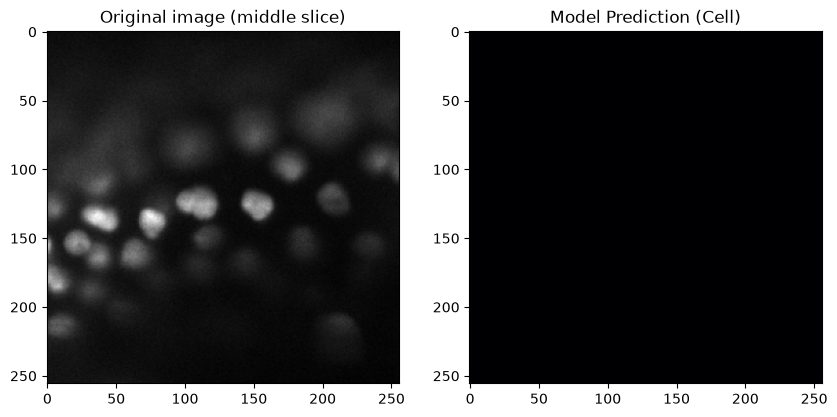

In [33]:
# test model
import torch
import zarr
import numpy as np
import matplotlib.pyplot as plt

# 1. Masukkan arsitektur 3D U-Net kamu di sini (copy-paste dari Kaggle)
# class UNet3D(nn.Module): 
#     ... 

# 2. Muat Model ke CPU
model = UNet3D()
# Trik sakti agar tidak error memori GPU di lokal:
model.load_state_dict(torch.load("model/results/best_unet3d.pth", map_location=torch.device('cpu')))
model.eval() # Matikan mode training

# 3. Buka 1 File Zarr
dataset = zarr.open(zarr_file_path, mode='r')

# Ambil gambar 3D-nya (biasanya array numpy)
# Sesuaikan indeks dengan struktur data zarr kompetisi ini
image_3d = dataset['0']
image_3d = image_3d[60, :, :, :]

img_min = image_3d.min()
img_max = image_3d.max()
image_normalized = (image_3d - img_min) / (img_max - img_min + 1e-8)

# 4. Ubah ke format PyTorch (Batch=1, Channel=1, Depth, Height, Width)
input_tensor = torch.tensor(image_normalized, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# 5. Lakukan Prediksi! (Sangat cepat karena cuma 1 file)
print("Inspecting cell...")
with torch.no_grad():
    print(f"Input Min: {input_tensor.min().item():.4f}")
    print(f"Input Max: {input_tensor.max().item():.4f}")
    raw_pred = model(input_tensor)
    mask_pred = torch.sigmoid(raw_pred)
    
    # Ubah hasil prediksi > 0.5 menjadi sel (1), sisanya background (0)
    final_mask = (mask_pred > 0.1).float()

# 6. Visualisasikan Irisan Tengahnya (biar kelihatan keren!)
# Mengambil layer z di tengah-tengah volume 3D
z_mid = image_3d.shape[0] // 2 

img_slice = image_3d[z_mid]
mask_slice = final_mask[0, 0, z_mid].numpy()

# Tampilkan bersebelahan
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_slice, cmap='gray')
axes[0].set_title("Original image (middle slice)")

axes[1].imshow(mask_slice, cmap='inferno') # Pakai warna inferno biar hasil prediksinya menyala
axes[1].set_title("Model Prediction (Cell)")

plt.show()

In [34]:
print("Nilai min probabilitas:", mask_pred.min().item())
print("Nilai max probabilitas:", mask_pred.max().item())
print("Rata-rata probabilitas:", mask_pred.mean().item())

Nilai min probabilitas: 3.723477960421856e-13
Nilai max probabilitas: 1.2168944962809292e-08
Rata-rata probabilitas: 8.943744633782558e-10


In [36]:
from cellpose import models

In [37]:
# Inisialisasi model (Cellpose akan otomatis mendownload bobotnya)
model = models.CellposeModel(gpu=False, model_type='cyto3')

# Cetak lokasi folder tempat Cellpose menyimpan file bobot tersebut
print(f"📁 Folder penyimpanan model: {models.MODEL_DIR}")

📁 Folder penyimpanan model: /home/okta/.cellpose/models


In [38]:
model_path = "cpsam_v2"

In [39]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models
from scipy.ndimage import center_of_mass

In [43]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models
from scipy.ndimage import center_of_mass

# 1. Sesuaikan Path File di Komputermu
ZARR_PATH =zarr_file_path  # Ganti dengan path .zarr lokalmu
MODEL_PATH = "cpsam_v2" # Ganti dengan path cpsam_v2 lokalmu

# 2. Fungsi Pembantu Membaca Array Zarr
def get_3d_array(zarr_node):
    if hasattr(zarr_node, "shape"):
        return zarr_node
    if hasattr(zarr_node, "keys"):
        for key in zarr_node.keys():
            res = get_3d_array(zarr_node[key])
            if res is not None:
                return res
    return None

print("Membaca file Zarr...")
zarr_root = zarr.open(ZARR_PATH, mode="r")
zarr_array = get_3d_array(zarr_root)

# Ambil frame pertama t=0 (Bentuk: Depth/Z, Height/Y, Width/X)
image_3d = zarr_array[0].astype(np.float32)
print(f"Ukuran Volume 3D: {image_3d.shape}")
small_crop = image_3d[10:20, 100:228, 100:228]


# 3. Muat Model Cellpose SAM v2
print("Memuat model Cellpose (cpsam_v2)...")
model = models.CellposeModel(gpu=False, pretrained_model=MODEL_PATH)

# 4. Jalankan Segmentasi 3D
print("Menjalankan Inferensi 3D...")
# 4. Jalankan Segmentasi 3D
print("Menjalankan Inferensi 3D...")
masks, flows, styles = model.eval(
    small_crop,
    do_3D=True,
    z_axis=0,        # <--- TAMBAHKAN BARIS INI
    anisotropy=4.0,  # Rasio resolusi Z dibanding XY (1.625 / 0.40625 ≈ 4.0)
    channels=[0, 0]  # Grayscale
)

num_cells = masks.max()
print(f"Selesai! Ditemukan {num_cells} sel unik dalam volume 3D.")

# 5. Ekstrak Titik Pusat Sel (Centroid) untuk Tracking
cell_ids = np.unique(masks)
cell_ids = cell_ids[cell_ids != 0]  # Abai latar belakang (0)
centroids = center_of_mass(masks, labels=masks, index=cell_ids)

if len(centroids) > 0:
    print(f"Contoh koordinat 3D sel pertama (Z, Y, X): {centroids[0]}")

# 6. Visualisasi Slice Tengah
mid_z = image_3d.shape[0] // 2
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image_3d[mid_z], cmap="gray")
axes[0].set_title(f"Gambar Asli (Slice Z={mid_z})")
axes[0].axis("off")

axes[1].imshow(masks[mid_z], cmap="nipy_spectral")
axes[1].set_title(f"Prediksi Cellpose 3D ({num_cells} Sel)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Membaca file Zarr...
Ukuran Volume 3D: (64, 256, 256)
Memuat model Cellpose (cpsam_v2)...
Menjalankan Inferensi 3D...
Menjalankan Inferensi 3D...


KeyboardInterrupt: 